# Variable-mean noise: LN models across a luminance step

**The experiment.** `VariableMeanNoise` delivers Gaussian noise of constant contrast **through
an LED** while the mean light level steps periodically. One epoch therefore contains steps in
both directions, and the question is how the cell's linear-nonlinear model changes as it adapts
to each new mean.

The protocol lives in two packages —
`edu.washington.riekelab.rieke.protocols.VariableMeanNoise` and
`edu.washington.riekelab.turner.protocols.VariableMeanNoise` — and they are the same protocol:
the recorded epoch parameters are identical, verified against the stored epochs rather than
assumed. Both are searched together and `protocol_name` says which one a block came from.


Model fitting is **cascadegraph**, vendored at `retinanalysis.utils.cascadegraph` — the Python
port of the library the MATLAB used. Nothing here reimplements a filter or a sigmoid.

In [1]:
import contextlib
import io
import json
import sys
import time
from pathlib import Path

if sys.version_info[:2] != (3, 11):
    raise RuntimeError(
        f'This notebook requires the retinanalysis Python 3.11 kernel; '
        f'got Python {sys.version.split()[0]} at {sys.executable}')
import_started = time.perf_counter()

import numpy as np
import pandas as pd
from IPython.display import display

import retinanalysis as ra
from retinanalysis.SCutils import explore as sc

# The analysis module sits beside this notebook: it is specific to this project.
sys.path.insert(0, str(Path.cwd()))
import variable_mean_noise as vmn

print(f'Python {sys.version.split()[0]} | {sys.executable}')
print(f'Imports ready in {time.perf_counter() - import_started:.2f} s')

Python 3.11.13 | /Users/chrischen/opt/anaconda3/envs/retinanalysis/bin/python
Imports ready in 0.43 s


### 1a. Recording type per block

These blocks carry no `onlineAnalysis`, so the amplifier decides. The epoch group's
`recordingTechnique` settles most of them; where it does not, series resistance above zero means
whole-cell with the polarity from the sign of the current (inward is `exc`, outward `inh`), and a
reading of exactly zero is confirmed against the trace, since it also happens when compensation
was never run.

Resolving a block that needs its trace is seconds per block, so this is **cached** to
`block_modes.csv` beside the notebook. Set `REFRESH_MODE_CACHE = True` to rebuild it (a few
minutes over ~400 blocks); otherwise it is read from disk.

In [2]:
REFRESH_MODE_CACHE = False

protocol_blocks = vmn.find_blocks(show=True, height=0)

if REFRESH_MODE_CACHE or not vmn.MODE_CACHE_PATH.exists():
    print(f'\nbuilding {vmn.MODE_CACHE_PATH.name} — a few minutes ...')
    vmn.build_mode_cache(protocol_blocks)

block_modes = vmn.load_block_modes()
print(f'\nrecording types over {len(block_modes)} cached blocks:')
print(block_modes.rec_type.value_counts(dropna=False).to_string())

protocol_cells = vmn.find_protocol_cells(protocol_blocks, modes=block_modes,
                                        show=True, height=460)


373 blocks | 46 experiments | 182 cells
  dropped 1227 block(s) with stimTime < 30 s
  dropped 120 block(s) on non-primate-RGC cell types
  by protocol: edu.washington.riekelab.rieke.protocols.VariableMeanNoise 262, edu.washington.riekelab.turner.protocols.VariableMeanNoise 111


exp_name,cell_label,cell_type_short,block_id,stim_seconds,led,ndfs,frequencyCutoff,numberOfFilters,Contrast,n_epochs,protocol_name
2020-06-11_B,Cell10,ON-parasol,30238,30.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,14,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell11,ON-midget,30209,60.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,2,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell11,ON-midget,30210,60.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,20,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell12,OFF-parasol,30188,30.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,15,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell13,ON-parasol,30174,30.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,19,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell13,ON-parasol,30177,30.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,6,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell14,ON-parasol,30216,30.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,14,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-11_B,Cell14,ON-parasol,30218,30.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,27,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-16_B,Cell3,ON-parasol,30318,60.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,10,edu.washington.riekelab.rieke.protocols.VariableMeanNoise
2020-06-16_B,Cell3,ON-parasol,30319,30.0,UV LED,"[""B4"",""FW2""]",60.0,4.0,0.5,11,edu.washington.riekelab.rieke.protocols.VariableMeanNoise



recording types over 373 cached blocks:
rec_type
extracellular    165
exc              116
none              76
inh               16


125 cells across 35 experiments
  dropped 54 cell(s) that ran only one light mean
  dropped 3 cell(s) that ran more than one contrast


exp_name,cell_index,cell_label,cell_type,n_extracellular,n_exc,n_inh,light_means,light_contrast,stim_seconds,led
2020-06-11_B,0,Cell10,ON-parasol,0,14,0,"0.3, 3",0.5,30,UV LED
,1,Cell11,ON-midget,0,22,0,"0.3, 3",0.5,60,UV LED
,2,Cell12,OFF-parasol,15,0,0,"0.3, 3",0.5,30,UV LED
,3,Cell13,ON-parasol,19,6,0,"0.3, 3",0.5,30,UV LED
,4,Cell14,ON-parasol,14,27,0,"0.3, 3",0.5,30,UV LED
2020-06-16_B,5,Cell3,ON-parasol,21,53,0,"0.08, 0.3, 0.8, 3",0.5,"30, 60",UV LED
2020-06-23_B,6,Cell10,OFF-parasol,10,0,0,"0.3, 3",0.5,30,UV LED
,7,Cell8,ON-midget,20,0,0,"0.1, 1",0.5,30,UV LED
2021-02-01_B,8,cell1,ON-parasol,62,0,0,"0.05, 0.08, 0.5, 1, 5",0.5,30,UV LED
,9,cell2,ON-midget,0,31,0,"0.05, 0.5, 5",0.5,30,UV LED


## 2. Analyze one cell condition

Set `CELL_INDEX` from §1 and `REC_TYPE` to the mode you want (`extracellular`, `exc` or `inh`).


2020-06-11_B | Cell13 (ON-parasol) | UV LED | lightMean 0.3, 3 | contrast 0.5 | 30 s
epochs: 19 extracellular, 6 exc, 0 inh

fitting extracellular blocks [30174]


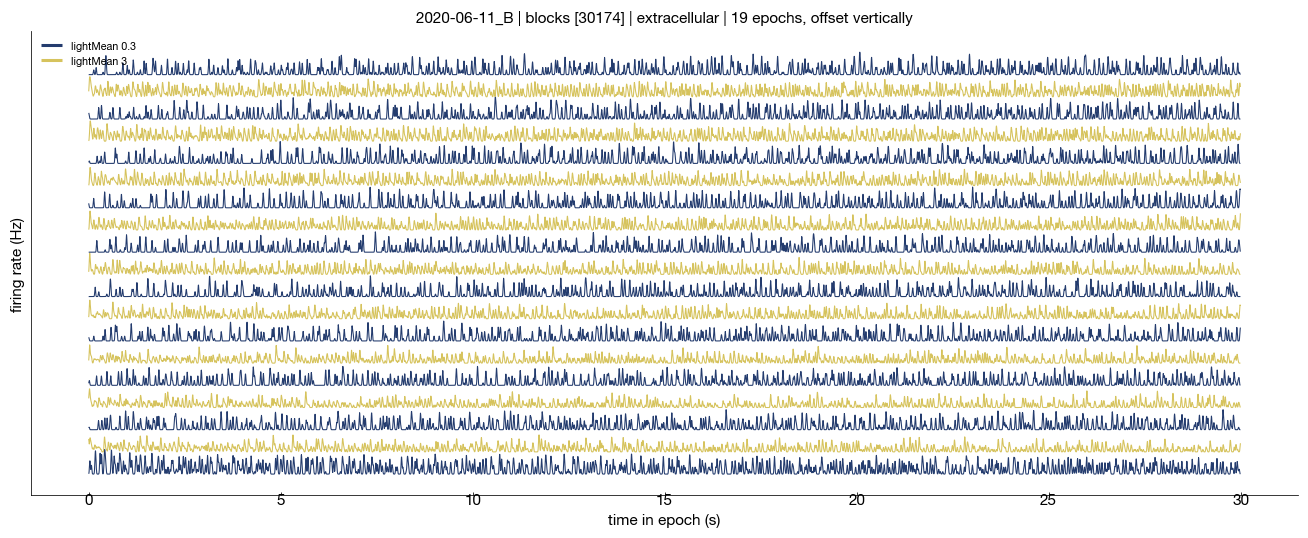

In [3]:
CELL_INDEX = 3
REC_TYPE = 'extracellular'   # 'extracellular', 'exc' or 'inh'
SKIP_SECONDS = 1.0           # drop the settling period at the start of each epoch
MAX_EPOCHS = None              # None for every epoch
DOWNSAMPLE = 10              # 10 kHz -> 1 kHz, by block average
WINDOW_SECONDS = 6.0         # how much of an epoch each data/model row shows

row = protocol_cells[protocol_cells.cell_index.eq(CELL_INDEX)].iloc[0]
print(f'{row.exp_name} | {row.cell_label} ({row.cell_type}) | {row.led} | '
      f'lightMean {row.light_means} | contrast {row.light_contrast} | '
      f'{row.stim_seconds} s')
print(f'epochs: {row.n_extracellular} extracellular, {row.n_exc} exc, {row.n_inh} inh')

EXP_NAME, BLOCK_IDS, rec_type = vmn.cell_blocks(
    protocol_cells, CELL_INDEX, rec_type=REC_TYPE, modes=block_modes)
print(f'\nfitting {rec_type} blocks {BLOCK_IDS}')

trace_figure = vmn.plot_traces(EXP_NAME, BLOCK_IDS, rec_type, max_epochs=MAX_EPOCHS)

### 2a. Group mean response

Drawn **before anything is fitted**, from the very arrays the models will be fitted to.
`analyze_condition(..., fit=False)` stops after loading, aligning and downsampling.

Every epoch has its own noise seed, so no two responses are alike, but they share the light mean
and the time since it stepped — the axis adaptation runs along. Averaging across the epochs of
one light mean, then within `MEAN_WINDOW_S` windows, leaves the slow course of the response.
Time-in-epoch is time-since-step, since the mean is constant within an epoch and changes between
them. It starts at `SKIP_SECONDS`; set that to 0 in §2 to see the very beginning.

extracellular: spike rate, so the whole-cell drift guards do not apply -- nothing to drift and no series resistance


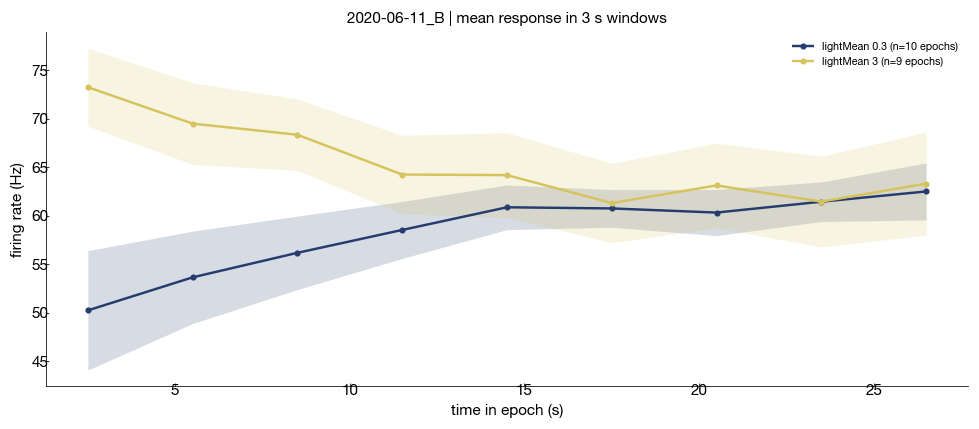

In [4]:
MEAN_WINDOW_S = 3.0
# exc / inh only -- neither runs for an extracellular recording, whatever is set here.
MAX_SERIES_RESISTANCE = 30e6   # drop epochs above this (ohms); None to keep all
ALIGN_EPOCH_MEANS = True       # bring epochs onto a common holding current

analysis = vmn.analyze_condition(
    EXP_NAME, BLOCK_IDS, rec_type=rec_type, skip_seconds=SKIP_SECONDS,
    downsample=DOWNSAMPLE, max_epochs=MAX_EPOCHS,
    max_series_resistance=MAX_SERIES_RESISTANCE,
    align_epoch_means=ALIGN_EPOCH_MEANS, fit=False, verbose=True)

if len(analysis.dropped_epochs):
    display(analysis.dropped_epochs)
if len(analysis.epoch_adjustments):
    display(analysis.epoch_adjustments.round(1))

mean_response_figure = vmn.plot_mean_response(analysis, window_s=MEAN_WINDOW_S)

### 2b. The LN model, and how it changes over the epoch

One model per light mean, then the same fit repeated in successive windows so the filter and the
nonlinearity can be watched changing as the cell adapts (`temporalLNModel.m`). Epochs are pooled
within a window — all of the first window together, then all of the second.

**Windows are sized to the epoch, not fixed.** `vmn.temporal_windows` takes as many windows of at
least `vmn.MIN_LN_WINDOW_S` as the usable stretch allows and divides it evenly, so nothing is
dropped: 29 s gives nine windows of 3.22 s rather than five of 5 s with the last 4 s discarded.
The count depends only on epoch length and `SKIP_SECONDS`, so cells recorded the same way get
windows that line up and can be pooled.

`MIN_LN_WINDOW_S` is 3 s because that was measured: a windowed fit keeps 90% of the full-stretch
held-out r² at 3 s and 94% at 5 s, but only 85% at 2 s and 64% at 0.5 s, where individual fits
diverge. That agrees with the degrees-of-freedom count — a filter band-limited to the stimulus
cutoff has about `2*f_c*L` parameters and a window supplies about `2*f_c*T*n` independent
samples, so 3 s over 7 epochs with a 1 s filter is ~21 samples per parameter.

The kinetics figure carries what those curves are doing: filter time-to-peak and biphasic index,
held-out r², and the nonlinearity's parameters against time-since-step. Rings mark a fit that
ended on a bound, where the parameter is set by the limit rather than by the data.

  lightMean 0.3: 10 epochs (8 train / 2 test) | r²=0.822 held out, 0.841 in sample | time-to-peak 32 ms


  lightMean 3: 9 epochs (7 train / 2 test) | r²=0.667 held out, 0.685 in sample | time-to-peak 59 ms

<ConditionAnalysis 2020-06-11_B blocks=[30174] | extracellular | lightMean 0.3, 3>
lightMean 0.3 -> 3 (10x brighter):
  time-to-peak   32 -> 59 ms
  biphasic index +0.28 -> -0.24


/Users/chrischen/Documents/GitHub/retinanalysis/SingCell_Notebooks/rodAdaptation/variable_mean_noise.py:2703: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=(0, 0, 1, 0.98))


,lightMean,n_epochs,n_train,n_test,r2,r2_train,nl_r2,time_to_peak_ms,biphasic_index,at_bounds
0,0.3,10,8,2,0.822,0.841,0.998,32.0,0.276,
1,3.0,9,7,2,0.667,0.685,1.000,59.0,-0.236,


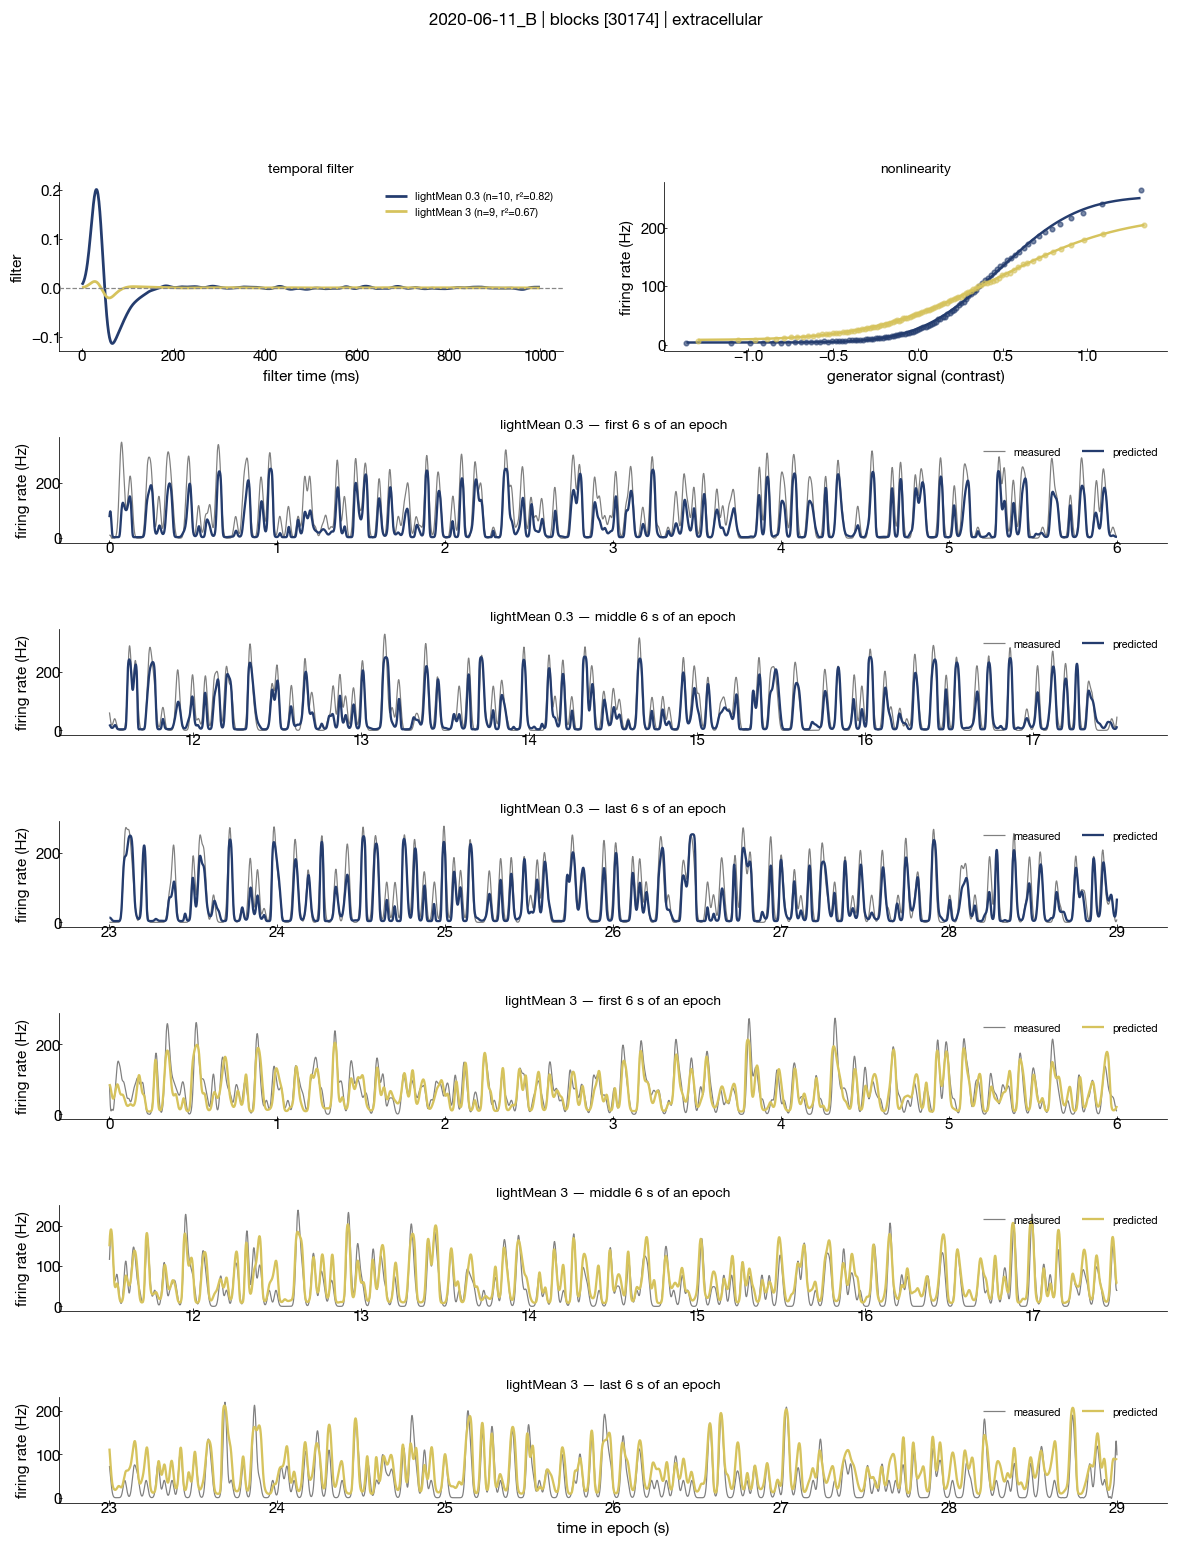

In [5]:
vmn.fit_condition(analysis, verbose=True)
print(f'\n{analysis}')

condition_figure = vmn.plot_condition(analysis, window_seconds=WINDOW_SECONDS)
summary = vmn.condition_summary(analysis, show=True)
display(summary.round(3))

  cutoff 60 Hz (the stimulus's own) | 9 windows of 3.22 s covering 29.00 s
  lightMean 0.3     1.0-4.2 s: 10 epochs pooled (8 train / 2 test) | r²=0.679 | time-to-peak 32 ms
  lightMean 0.3     4.2-7.4 s: 10 epochs pooled (8 train / 2 test) | r²=0.732 | time-to-peak 32 ms


  lightMean 0.3    7.4-10.7 s: 10 epochs pooled (8 train / 2 test) | r²=0.775 | time-to-peak 32 ms
  lightMean 0.3   10.7-13.9 s: 10 epochs pooled (8 train / 2 test) | r²=0.809 | time-to-peak 32 ms
  lightMean 0.3   13.9-17.1 s: 10 epochs pooled (8 train / 2 test) | r²=0.818 | time-to-peak 31 ms


  lightMean 0.3   17.1-20.3 s: 10 epochs pooled (8 train / 2 test) | r²=0.809 | time-to-peak 31 ms
  lightMean 0.3   20.3-23.6 s: 10 epochs pooled (8 train / 2 test) | r²=0.803 | time-to-peak 31 ms


  lightMean 0.3   23.6-26.8 s: 10 epochs pooled (8 train / 2 test) | r²=0.802 | time-to-peak 31 ms
  lightMean 0.3   26.8-30.0 s: 10 epochs pooled (8 train / 2 test) | r²=0.823 | time-to-peak 31 ms
  lightMean 3     1.0-4.2 s: 9 epochs pooled (7 train / 2 test) | r²=0.639 | time-to-peak 58 ms


  lightMean 3     4.2-7.4 s: 9 epochs pooled (7 train / 2 test) | r²=0.637 | time-to-peak 59 ms
  lightMean 3    7.4-10.7 s: 9 epochs pooled (7 train / 2 test) | r²=0.678 | time-to-peak 59 ms
  lightMean 3   10.7-13.9 s: 9 epochs pooled (7 train / 2 test) | r²=0.650 | time-to-peak 59 ms


  lightMean 3   13.9-17.1 s: 9 epochs pooled (7 train / 2 test) | r²=0.653 | time-to-peak 59 ms
  lightMean 3   17.1-20.3 s: 9 epochs pooled (7 train / 2 test) | r²=0.630 | time-to-peak 60 ms
  lightMean 3   20.3-23.6 s: 9 epochs pooled (7 train / 2 test) | r²=0.620 | time-to-peak 60 ms


  lightMean 3   23.6-26.8 s: 9 epochs pooled (7 train / 2 test) | r²=0.590 | time-to-peak 60 ms
  lightMean 3   26.8-30.0 s: 9 epochs pooled (7 train / 2 test) | r²=0.577 | time-to-peak 60 ms


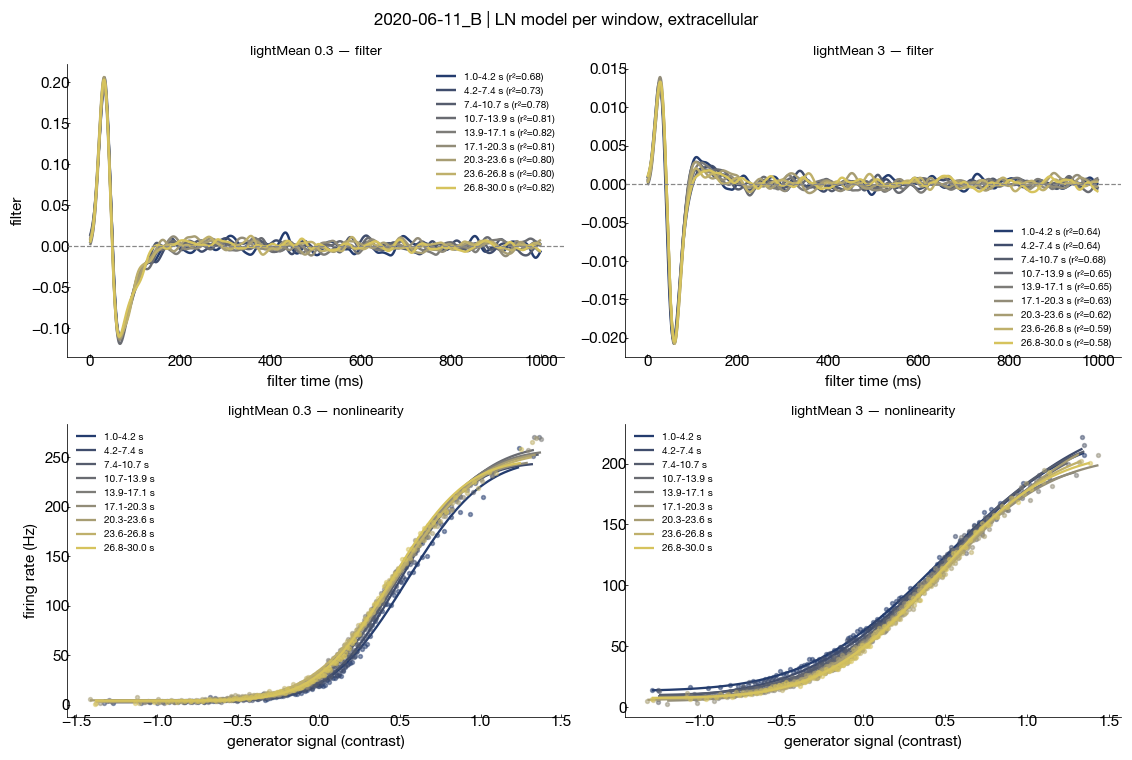

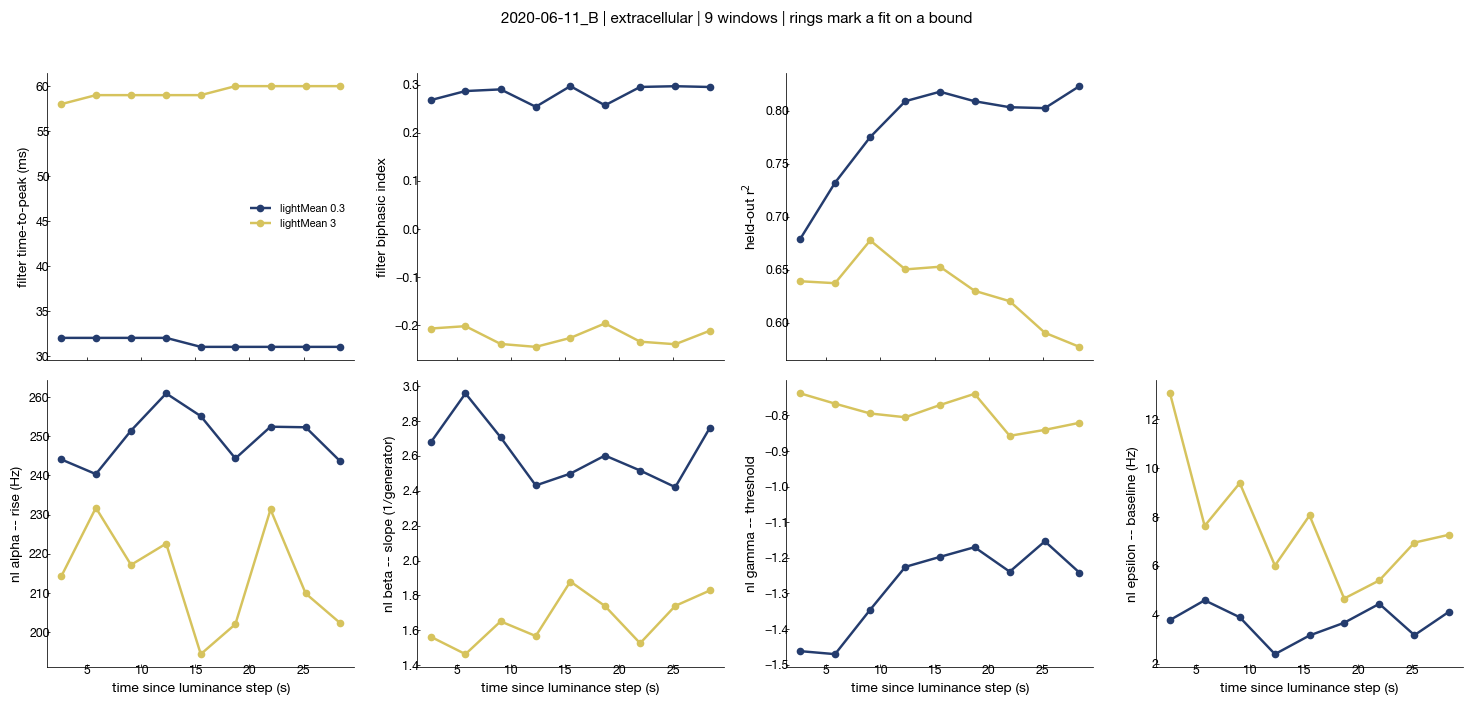

In [6]:
# window_seconds=None -> vmn.temporal_windows sizes them from the epoch length.
# frequency_cutoff defaults to the stimulus's own; pass it only to fit below that.
temporal_models = vmn.temporal_ln_model(analysis, window_seconds=None, verbose=True)

temporal_figure = vmn.plot_temporal_ln(analysis, temporal_models)
kinetics_figure = vmn.plot_temporal_kinetics(analysis, temporal_models)

## 3. LED light level

The LED's own neutral density filters set the light level. A `FilterWheel` NDF is real — the
wheel exists on the rig — but it is **not in the LED's path**, so it must not be added to this
stimulus's attenuation. `led_attenuation` returns it separately with `wheel_ignored` set, rather
than dropping it silently, because the same metadata is correct for a Stage protocol and wrong
here.

A filter with no entry in the rig's LED table leaves `optical_density` blank and is named in
`unknown_tokens`, so an unknown filter cannot masquerade as no attenuation.

In [7]:
light = vmn.light_level_table(protocol_blocks, show=True)

sc.scroll_table(
    light[['exp_name', 'rig', 'led', 'led_ndfs', 'optical_density', 'attenuation',
           'wheel_tokens_ignored', 'unknown_tokens', 'n_blocks']].round(4),
    height=340, num_cols=('optical_density', 'attenuation', 'n_blocks'))

46 experiment x LED combinations | 2 list an FW filter that is not in the LED path (stripped, named in wheel_tokens_ignored)
7 with filters missing from the rig LED table: ['E7', 'G5']


exp_name,rig,led,led_ndfs,optical_density,attenuation,wheel_tokens_ignored,unknown_tokens,n_blocks
2020-06-11_B,two_photon,UV LED,B4,2.54,0.0029,FW2,,8
2020-06-16_B,two_photon,UV LED,B4,2.54,0.0029,FW2,,8
2020-06-23_B,two_photon,UV LED,(none),0.0,1.0,,,3
2020-07-13_G,shared_two_photon,Red LED,(none),0.0,1.0,,,3
2020-07-14_G,shared_two_photon,Red LED,(none),0.0,1.0,,,8
2020-07-29_G,shared_two_photon,UV LED,(none),0.0,1.0,,,18
2020-08-11_G,shared_two_photon,UV LED,(none),0.0,1.0,,,17
2020-08-25_G,shared_two_photon,UV LED,(none),0.0,1.0,,,8
2020-08-25_G_scotopic,shared_two_photon,UV LED,"G7, G8, G9",4.07,0.0001,,,4
2020-10-20_G,shared_two_photon,UV LED,(none),0.0,1.0,,,6


'\n<style>\n.ra-tbl { overflow: auto; }\n.ra-tbl table { border-collapse: collapse; font-size: 12.5px;\n                font-variant-numeric: tabular-nums; }\n.ra-tbl th { position: sticky; top: 0; z-index: 1; text-align: left;\n             font-weight: 600; padding: 4px 12px 4px 0;\n             border-bottom: 1px solid rgba(128,128,128,0.6);\n             background: var(--jp-layout-color0, #fff); }\n.ra-tbl td { padding: 2px 12px 2px 0; vertical-align: top;\n             white-space: nowrap; }\n.ra-tbl tr.grp > td { border-top: 1px solid rgba(128,128,128,0.28); }\n.ra-tbl td.num { text-align: right; }\n.ra-tbl td.lead { font-weight: 600; }\n.ra-tbl summary { cursor: pointer; margin: 2px 0; }\n</style>\n<div class="ra-tbl" style="max-height:340px"><table><thead><tr><th>exp_name</th><th>rig</th><th>led</th><th>led_ndfs</th><th>optical_density</th><th>attenuation</th><th>wheel_tokens_ignored</th><th>unknown_tokens</th><th>n_blocks</th></tr></thead><tbody><tr><td>2020-06-11_B</td><td>t

## 4. The saved MATLAB summary, for comparison

`matlabSummary/rodVariableMeanNoise.mat` holds the 53 cells the MATLAB analysis was run on,
with its own fitted LN models. It is **not** an input to anything above — the analysis here runs
from the recordings. It is kept so the Python population summary can be compared against the
MATLAB's once there is one.

One thing to know when matching them up: the saved `expDate` is **two days early**, across the
board. `vmn.resolve_roster_files` applies that correction and confirms each cell by label
(case-sensitively) and type; `vmn.SAVED_DATE_OFFSET_DAYS` is the constant. That is only needed
for the comparison, so it is not run here.

In [8]:
roster = vmn.load_summary(show=True)

sc.scroll_table(
    roster[['index', 'exp_date', 'cell_label', 'cell_type', 'rec_type',
            'epoch_len_ms', 'tau_low', 'tau_high', 'is_example']].round(2),
    height=300, num_cols=('index', 'epoch_len_ms', 'tau_low', 'tau_high'))

print(f'\nsaved dates are {vmn.SAVED_DATE_OFFSET_DAYS} days early; '
      f'vmn.resolve_roster_files() corrects and confirms them when needed.')

53 saved cells | 16 dates | 15 rows in duplicated groups
rec_type   exc  extracellular
cell_type                    
OnMidget    11             10
OnParasol   14             18


index,exp_date,cell_label,cell_type,rec_type,epoch_len_ms,tau_low,tau_high,is_example
0,2020/07/27,cell5,OnParasol,extracellular,60000.0,11.87,15.94,False
1,2020/08/23,cell3,OnParasol,extracellular,55000.0,10.59,14.76,True
2,2020/08/23,cell6,OnParasol,extracellular,56000.0,9.07,0.05,True
3,2020/08/23,cell7,OnParasol,extracellular,60000.0,7.33,25909.59,True
4,2020/08/09,cell1,OnMidget,extracellular,60000.0,7.38,12.81,False
5,2020/08/09,cell3,OnParasol,extracellular,50000.0,9.54,12.29,False
6,2020/08/23,cell4,OnMidget,extracellular,55000.0,16.2,14.03,False
7,2021/04/25,cell1,OnParasol,extracellular,50000.0,7.0,7.65,True
8,2021/04/25,cell2,OnParasol,extracellular,50000.0,5.53,39.91,True
9,2021/04/25,cell3,OnParasol,extracellular,50000.0,6.06,28.17,True



saved dates are 2 days early; vmn.resolve_roster_files() corrects and confirms them when needed.
